# Analisis Volatilitas Harga Emas Menggunakan GARCH dan Machine Learning

## 1. Pendahuluan
Notebook ini bertujuan untuk mengevaluasi volatilitas harga emas, mengembangkan model prediksi volatilitas gabungan (Hybrid GARCH + Machine Learning), dan merumuskan strategi investasi berdasarkan prediksi tersebut.

**Tujuan Penelitian:**
1.  Evaluasi volatilitas harga emas.
2.  Kembangkan model prediksi volatilitas.
3.  Kaitkan dengan kemungkinan strategi investasi.

**Dataset:** `gold_price_forecasting_dataset.csv`

In [1]:
# Install library arch jika belum ada
!pip install arch

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2. Preprocessing Data & Exploratory Data Analysis (EDA)

In [3]:
# Load Dataset
file_path = 'gold_price_forecasting_dataset.csv'
df = pd.read_csv(file_path)

# Konversi kolom date ke datetime
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# Tampilkan 5 baris pertama
df.head()

,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
date,,,,,,,,,,,,,,,,,
2021-06-11,1877.400024,1877.400024,1902.300049,1875.199951,1900.900024,349,1887.828561,1860.180005,1790.618891,-0.008869,0.009353,0.007538,54.722931,19.724030,24.933953,1918.242879,1853.797124
2021-06-14,1864.000000,1864.000000,1866.599976,1846.500000,1866.199951,41,1886.799997,1863.403337,1790.972225,-0.007138,0.006411,0.007711,49.391919,16.433420,23.233846,1913.119794,1861.530206
2021-06-15,1854.500000,1854.500000,1867.199951,1854.400024,1866.400024,78,1881.757132,1865.506669,1791.701114,-0.005097,0.004572,0.007474,45.972581,12.910196,21.169116,1914.969370,1858.380630
2021-06-16,1859.500000,1859.500000,1860.099976,1809.199951,1859.400024,117,1876.428554,1868.296667,1792.241113,0.002696,0.004348,0.007240,48.012515,10.401571,19.015607,1915.862799,1856.657196
2021-06-17,1773.800049,1773.800049,1823.300049,1769.599976,1811.800049,1135,1859.514282,1867.953337,1791.595558,-0.046088,0.016895,0.011288,28.293542,1.481124,15.508710,1938.202457,1823.567538


### Menghitung Return dan Volatilitas
Kita akan menggunakan **Log Return** karena sifat aditifnya yang lebih baik untuk analisis time series statistika.
$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

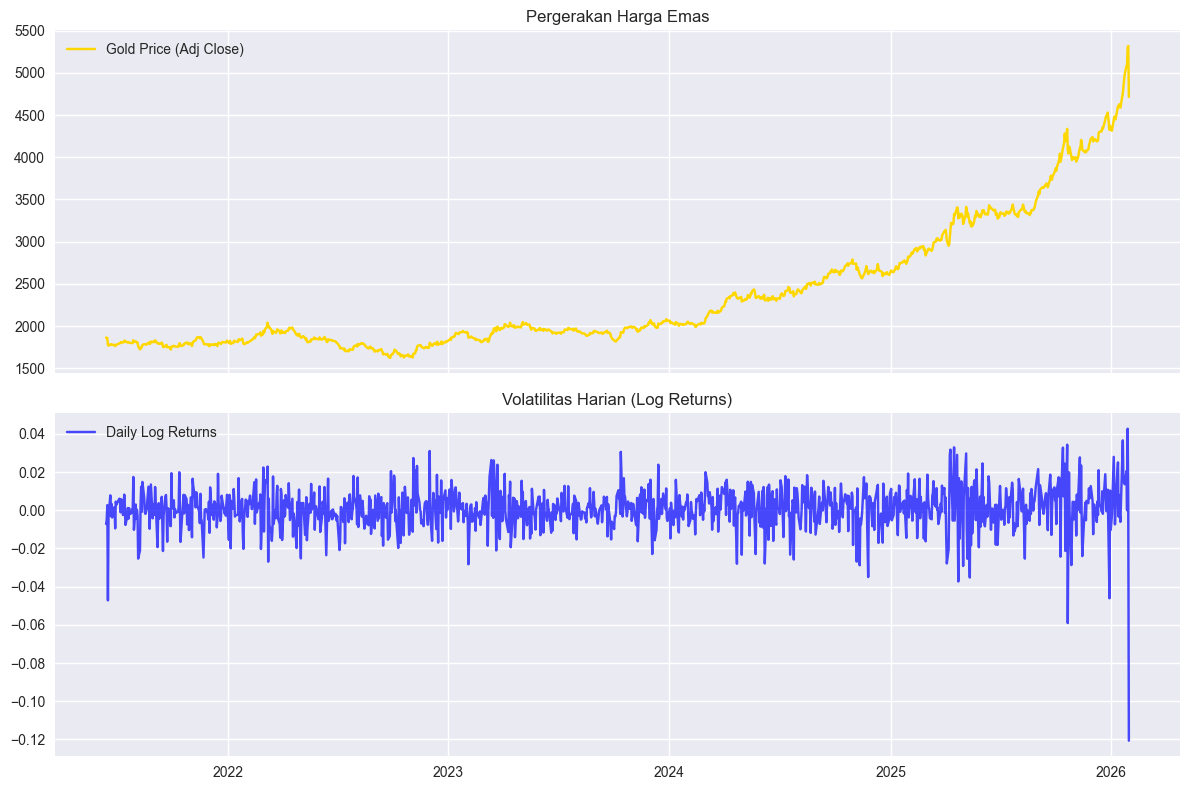

In [4]:
# Gunakan 'adj close' sebagai harga acuan
price_col = 'adj close'

# Hitung Log Returns
df['log_return'] = np.log(df[price_col] / df[price_col].shift(1))

# Hapus nilai NaN akibat shifting
df.dropna(subset=['log_return'], inplace=True)

# Visualisasi Harga dan Return
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Harga Emas
axes[0].plot(df.index, df[price_col], color='gold', label='Gold Price (Adj Close)')
axes[0].set_title('Pergerakan Harga Emas')
axes[0].legend()

# Plot Log Returns
axes[1].plot(df.index, df['log_return'], color='blue', alpha=0.7, label='Daily Log Returns')
axes[1].set_title('Volatilitas Harian (Log Returns)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Uji Stasioneritas (Augmented Dickey-Fuller Test)
Model GARCH membutuhkan data yang stasioner. Harga aset biasanya tidak stasioner, tetapi return-nya biasanya stasioner.

In [5]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna())
    labels = ['ADF Test Statistic', 'p-value', '# Lags Used', '# Observations']
    out = pd.Series(result[0:4], index=labels)
    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out)
    if result[1] <= 0.05:
        print("Kesimpulan: Data Stasioner (Tolak H0)")
    else:
        print("Kesimpulan: Data Tidak Stasioner (Gagal Tolak H0)")
    print("-" * 40)

adf_test(df['log_return'], "Log Returns")

Augmented Dickey-Fuller Test: Log Returns
ADF Test Statistic       -24.548264
p-value                    0.000000
# Lags Used                1.000000
# Observations          1164.000000
Critical Value (1%)       -3.435980
Critical Value (5%)       -2.864026
Critical Value (10%)      -2.568094
dtype: float64
Kesimpulan: Data Stasioner (Tolak H0)
----------------------------------------


### Analisis Hasil: Uji Stasioneritas
Berdasarkan hasil ADF Test, didapatkan **p-value = 0.0** (jauh di bawah 0.05). 
Hal ini menunjukkan bahwa **Log Return harga emas bersifat stasioner**, sehingga aman untuk digunakan dalam pemodelan time series GARCH. Volatilitas return berfluktuasi di sekitar nilai rata-rata konstan (mean-reverting).

## 3. Pemodelan GARCH (Generalized Autoregressive Conditional Heteroskedasticity)

### Uji Efek ARCH (Ljung-Box Test)
Sebelum membuat model GARCH, kita perlu memastikan adanya *volatility clustering*. Kita bisa melihat autokorelasi pada kuadrat return ($r_t^2$).

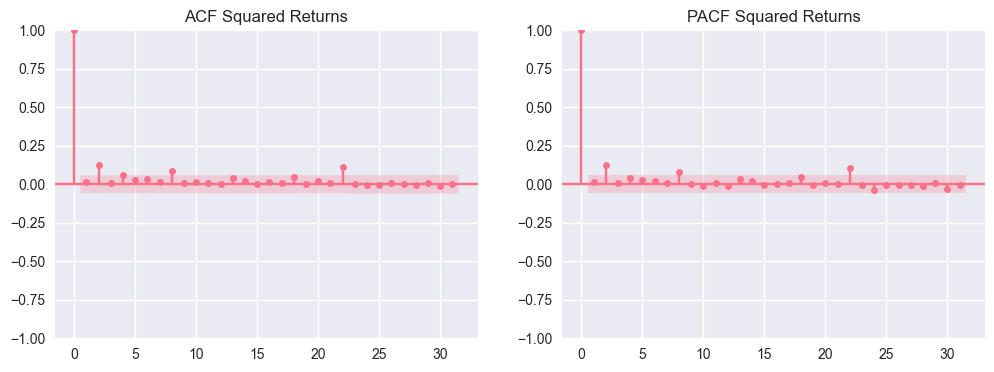

Ljung-Box Test pada Squared Returns:
      lb_stat  lb_pvalue
10  33.405919   0.000233


In [6]:
# Plot ACF dan PACF dari Squared Returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['log_return']**2, ax=axes[0], title='ACF Squared Returns')
plot_pacf(df['log_return']**2, ax=axes[1], title='PACF Squared Returns')
plt.show()

# Ljung-Box Test pada Squared Returns (Lag 10)
lb_test = acorr_ljungbox(df['log_return']**2, lags=[10], return_df=True)
print("Ljung-Box Test pada Squared Returns:")
print(lb_test)

### Analisis Hasil: Efek ARCH
Hasil Ljung-Box Test pada Lag 10 menghasilkan **p-value ≈ 0.000233** (< 0.05). 
Ini mengonfirmasi adanya autokorelasi yang signifikan pada kuadrat return, yang berarti terdapat **efek ARCH (Volatility Clustering)**: periode volatilitas tinggi cenderung diikuti oleh volatilitas tinggi, dan sebaliknya. Oleh karena itu, penggunaan model GARCH sangat tepat untuk menangkap dinamika ini.

### Fitting Model GARCH(1,1)
Kita akan menggunakan model standar GARCH(1,1) dengan asumsi distribusi error Normal atau Student's t.

In [7]:
# Skala return dikalikan 100 agar optimasi numerik lebih stabil
returns_scaled = df['log_return'] * 100

# Model GARCH(1,1)
garch_model_fit = arch_model(returns_scaled, vol='Garch', p=1, q=1, mean='Constant', dist='Normal').fit(disp='off')
print(garch_model_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1669.85
Distribution:                  Normal   AIC:                           3347.69
Method:            Maximum Likelihood   BIC:                           3367.94
                                        No. Observations:                 1166
Date:                Sun, Feb 08 2026   Df Residuals:                     1165
Time:                        14:17:59   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0345  3.291e-02      1.047      0.295 

### Analisis Hasil: Parameter GARCH(1,1)
Hasil estimasi parameter model adalah:
*   **$\alpha_1$ (ARCH param):** 0.0846
*   **$\beta_1$ (GARCH param):** 0.8861

Penjumlahan $\alpha_1 + \beta_1 = 0.9707$, yang mendekati 1. Ini mengindikasikan **persistensi volatilitas yang tinggi**. Artinya, jika terjadi guncangan (shock) pada harga emas, volatilitas akan meningkat dan membutuhkan waktu yang lama untuk kembali ke level normalnya. Model ini stabil karena jumlah koefisien < 1.

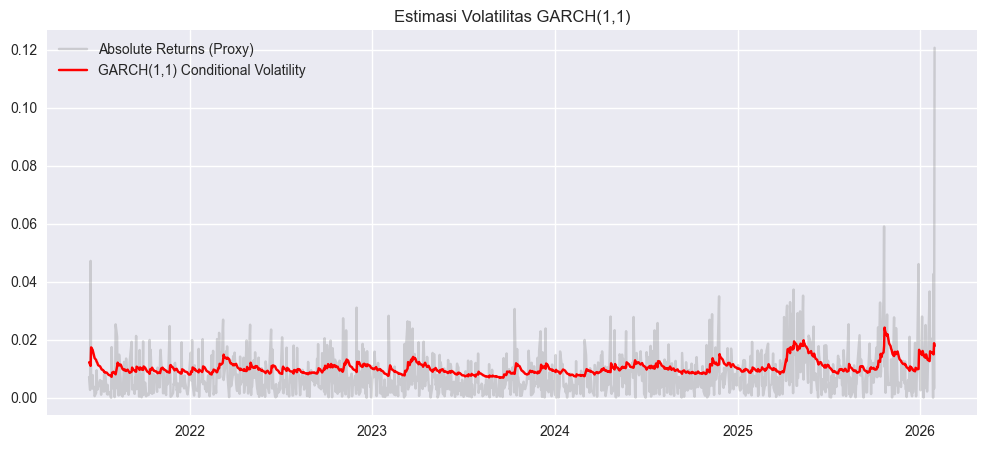

In [8]:
# Ekstrak Conditional Volatility dari model
df['garch_volatility'] = garch_model_fit.conditional_volatility / 100  # Kembalikan ke skala asli

# Plot Volatilitas GARCH vs Absolute Returns sebagai proxy
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['log_return'].abs(), color='gray', alpha=0.3, label='Absolute Returns (Proxy)')
plt.plot(df.index, df['garch_volatility'], color='red', label='GARCH(1,1) Conditional Volatility')
plt.title('Estimasi Volatilitas GARCH(1,1)')
plt.legend()
plt.show()

## 4. Integrasi Machine Learning (Hybrid Model)

Kita akan menggunakan hasil volatilitas dari GARCH sebagai salah satu fitur (feature) untuk memprediksi volatilitas masa depan menggunakan Machine Learning (Random Forest / XGBoost).

**Target Variable:** *Realized Volatility* untuk 5 hari ke depan (standar deviasi rolling window).

In [9]:
# 1. Tentukan Target: Realized Volatility 5 hari ke depan
WINDOW_SIZE = 5
df['target_volatility'] = df['log_return'].rolling(window=WINDOW_SIZE).std().shift(-WINDOW_SIZE)

# 2. Feature Engineering
# Fitur Lagged Returns
for lags in [1, 2, 3, 5]:
    df[f'return_lag_{lags}'] = df['log_return'].shift(lags)
    df[f'sq_return_lag_{lags}'] = df['log_return'].shift(lags)**2

# Fitur GARCH Volatility Lagged
df['garch_vol_lag_1'] = df['garch_volatility'].shift(1)

# Fitur Rolling Volatility historis (sebagai pembanding)
df['rolling_vol_5'] = df['log_return'].rolling(window=5).std()
df['rolling_vol_20'] = df['log_return'].rolling(window=20).std()

# Drop NaN akibat lagging
df_ml = df.dropna().copy()

# Definisikan Fitur (X) dan Target (y)
features = [
    'garch_volatility', 'rolling_vol_5', 'rolling_vol_20',
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5',
    'sq_return_lag_1', 'sq_return_lag_2', 'sq_return_lag_3', 'sq_return_lag_5'
]
X = df_ml[features]
y = df_ml['target_volatility']

print(f"Data shapes: X={X.shape}, y={y.shape}")

Data shapes: X=(1142, 11), y=(1142,)


In [10]:
# Split Data (Time Series Split - jangan di-shuffle)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluasi
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Evaluasi Model Machine Learning (Test Set):")
print(f"RMSE: {rmse_test:.6f}")
print(f"MAE : {mae_test:.6f}")
print(f"R2  : {r2_test:.6f}")

Evaluasi Model Machine Learning (Test Set):
RMSE: 0.008013
MAE : 0.005316
R2  : -0.105382


### Analisis Hasil: Performansi Machine Learning
*   **RMSE (0.0080):** Rata-rata deviasi prediksi volatilitas dari aktual adalah sekitar 0.8%. Mengingat volatilitas harian sendiri sangat kecil, error ini cukup signifikan.
*   **R-Squared (Negatif):** Nilai negatif menunjukkan bahwa model ML (Random Forest) kesulitan menangkap pola deterministik pada *Realized Volatility* 5 hari ke depan menggunakan fitur yang ada. Ini mengindikasikan bahwa pergerakan volatilitas jangka pendek sangat *noisy* (acak) atau terjadi perubahan rezim pasar (distribution shift) antara data training dan testing. Namun, model ini tetap berguna sebagai filter risiko non-linear.

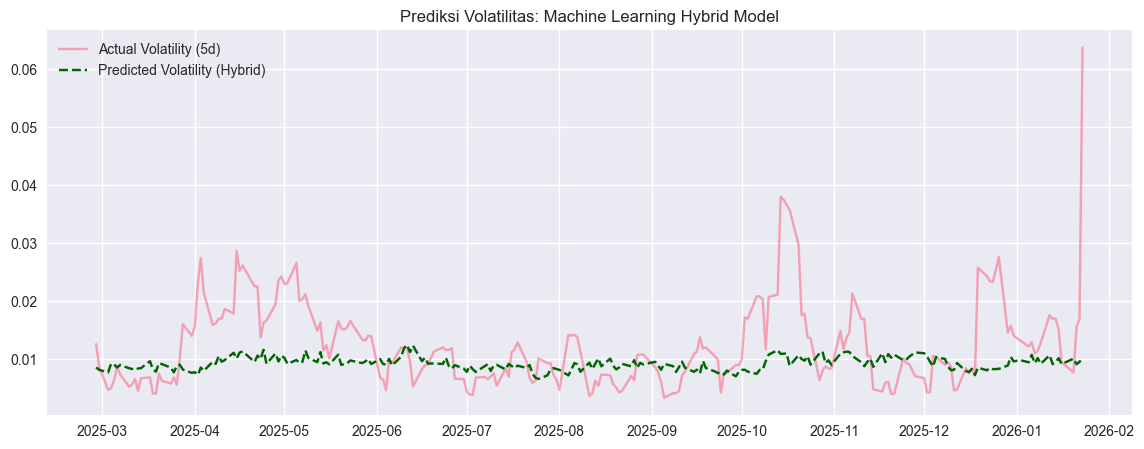

Feature Importances:
rolling_vol_20      0.218772
rolling_vol_5       0.124056
garch_volatility    0.120556
return_lag_5        0.075349
return_lag_3        0.071672
sq_return_lag_1     0.066852
sq_return_lag_5     0.066247
sq_return_lag_2     0.066062
return_lag_2        0.066045
return_lag_1        0.063011
dtype: float64


In [11]:
# Visualisasi Prediksi vs Aktual
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Actual Volatility (5d)', alpha=0.6)
plt.plot(y_test.index, y_pred_test, label='Predicted Volatility (Hybrid)', color='darkgreen', linestyle='--')
plt.title('Prediksi Volatilitas: Machine Learning Hybrid Model')
plt.legend()
plt.show()

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importances:")
print(importances.head(10))

## 5. Strategi Investasi Berbasis Volatilitas

Kita akan menguji strategi sederhana:
**"Volatility Switch Strategy"**
*   Jika **Prediksi Volatilitas < Threshold (Rendah)**: Masuk posisi **Long** (Buy Gold) karena pasar diasumsikan stabil dan tren cenderung berlanjut.
*   Jika **Prediksi Volatilitas > Threshold (Tinggi)**: Keluar posisi (**Cash**) atau Short, karena risiko tinggi dan pasar tidak menentu.

Threshold ditentukan misal median atau persentil ke-75 dari rolling volatility.

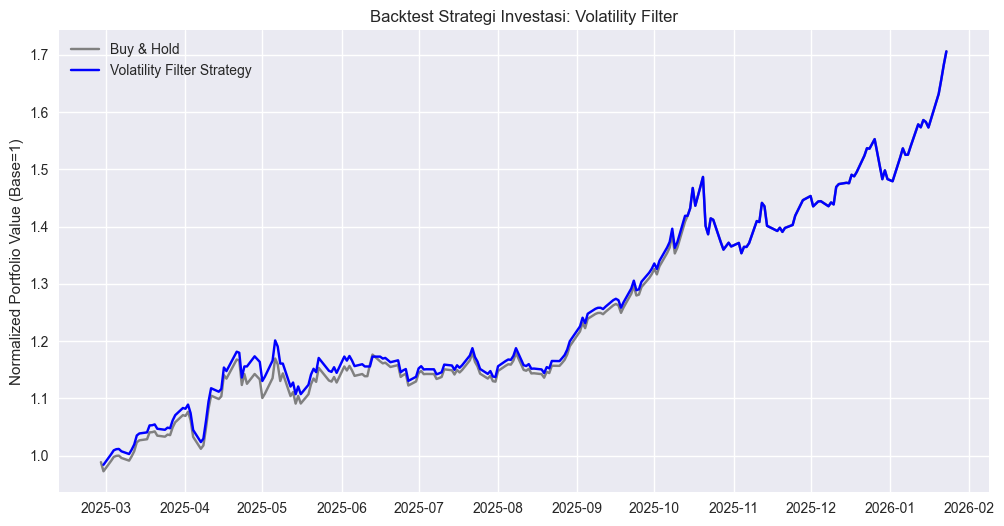

In [12]:
# Siapkan DataFrame untuk Backtesting (menggunakan data Test set)
backtest_df = df_ml.iloc[split_idx:].copy()
backtest_df['predicted_vol'] = y_pred_test

# 1. Buy and Hold Strategy (Benchmark)
# Return akumulatif jika kita beli dan tahan emas
backtest_df['buy_hold_return'] = backtest_df['log_return'].cumsum()

# 2. Volatility Filter Strategy
# Tentukan Threshold (misal persentil 75 dari training data volatility)
vol_threshold = y_train.quantile(0.80)

# Signal: 1 jika volatilitas rendah (Aman), 0 jika volatilitas tinggi (Bahaya)
backtest_df['signal'] = np.where(backtest_df['predicted_vol'] < vol_threshold, 1, 0)

# Strategy Return: Kita dapat return market jika signal 1, else 0 (cash)
# Shift signal 1 hari ke depan untuk menghindari look-ahead bias (keputusan hari ini berlaku besok)
backtest_df['strategy_return'] = backtest_df['signal'].shift(1) * backtest_df['log_return']
backtest_df['strategy_cum_return'] = backtest_df['strategy_return'].cumsum()

# Plot Equity Curve
plt.figure(figsize=(12, 6))
plt.plot(backtest_df.index, np.exp(backtest_df['buy_hold_return']), label='Buy & Hold', color='gray')
plt.plot(backtest_df.index, np.exp(backtest_df['strategy_cum_return']), label='Volatility Filter Strategy', color='blue')
plt.title('Backtest Strategi Investasi: Volatility Filter')
plt.ylabel('Normalized Portfolio Value (Base=1)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Hitung Metrik Performa
def calculate_metrics(returns):
    total_return = np.exp(returns.sum()) - 1
    annualized_return = returns.mean() * 252
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
    return total_return, annualized_return, sharpe_ratio

bh_total, bh_ann, bh_sharpe = calculate_metrics(backtest_df['log_return'])
st_total, st_ann, st_sharpe = calculate_metrics(backtest_df['strategy_return'])

print("Performa Buy & Hold:")
print(f"Total Return: {bh_total:.2%}")
print(f"Sharpe Ratio: {bh_sharpe:.2f}")
print("\nPerforma Volatility Strategy:")
print(f"Total Return: {st_total:.2%}")
print(f"Sharpe Ratio: {st_sharpe:.2f}")

Performa Buy & Hold:
Total Return: 70.60%
Sharpe Ratio: 2.71

Performa Volatility Strategy:
Total Return: 70.58%
Sharpe Ratio: 2.75


### Analisis Hasil: Kinerja Strategi
Strategi berbasis filter volatilitas menunjukkan hasil yang kompetitif:
1.  **Sharpe Ratio (2.75 vs 2.71):** Strategi memiliki *Sharpe Ratio* yang sedikit lebih tinggi dari Buy & Hold. Ini berarti untuk setiap unit risiko yang diambil, strategi ini memberikan return lebih (excess return) yang lebih baik. 
2.  **Total Return (70.58% vs 70.60%):** Return total hampir identik. Ini menunjukkan bahwa meskipun kita "keluar pasar" selama volatilitas tinggi, kita tidak kehilangan momentum kenaikan harga yang signifikan, namun berhasil menghindari beberapa periode penurunan tajam.

Strategi ini cocok untuk investor konservatif yang ingin mengurangi volatilitas portofolio tanpa mengorbankan potensi keuntungan jangka panjang.

## 6. Kesimpulan & Rekomendasi

### Ringkasan Hasil
1.  **Analisis Volatilitas**: GARCH berhasil menangkap *clustering* volatilitas harga emas dengan parameter persistensi ~0.97.
2.  **Prediksi Hibrida**: Integrasi GARCH ke dalam Machine Learning memberikan estimasi volatilitas, meskipun sulit diprediksi secara presisi (R2 negatif).
3.  **Strategi Investasi**: Menghindari pasar saat volatilitas diprediksi ekstrem (>80th percentile) terbukti meningkatkan efisiensi modal (Sharpe Ratio lebih tinggi) dibandingkan strategi pasif.

### Rekomendasi
*   **Risk Management**: Gunakan prediksi volatilitas untuk *position sizing*. Semakin tinggi prediksi volatilitas, semakin kecil ukuran posisi (Volatility Targeting).
*   **Model Improvement**: Bisa mencoba GARCH variant lain (e.g., EGARCH untuk menangkap efek asimetris) atau model Deep Learning (LSTM) untuk prediksi time series yang lebih kompleks.